PCA实现完整演示
=== PCA实现演示 ===
原始数据形状: (200, 2)
原始数据前5行:
[[-0.80215071 -0.88959673]
 [-1.58459817 -0.62134951]
 [ 0.47278944  0.32470822]
 [-2.93198669 -2.44661835]
 [ 0.62791352  0.97105862]]

1. 自定义PCA实现
主成分形状: (200, 2)
主成分前5行:
[[-1.18138736 -0.0727039 ]
 [-1.54091216  0.67222731]
 [ 0.57851385 -0.12520754]
 [-3.78613463  0.34659222]
 [ 1.14713354  0.21903651]]
解释方差比例: [0.96621311 0.03378689]
累积解释方差: [0.96621311 1.        ]

2. 与sklearn PCA对比
Sklearn解释方差比例: [0.96621311 0.03378689]


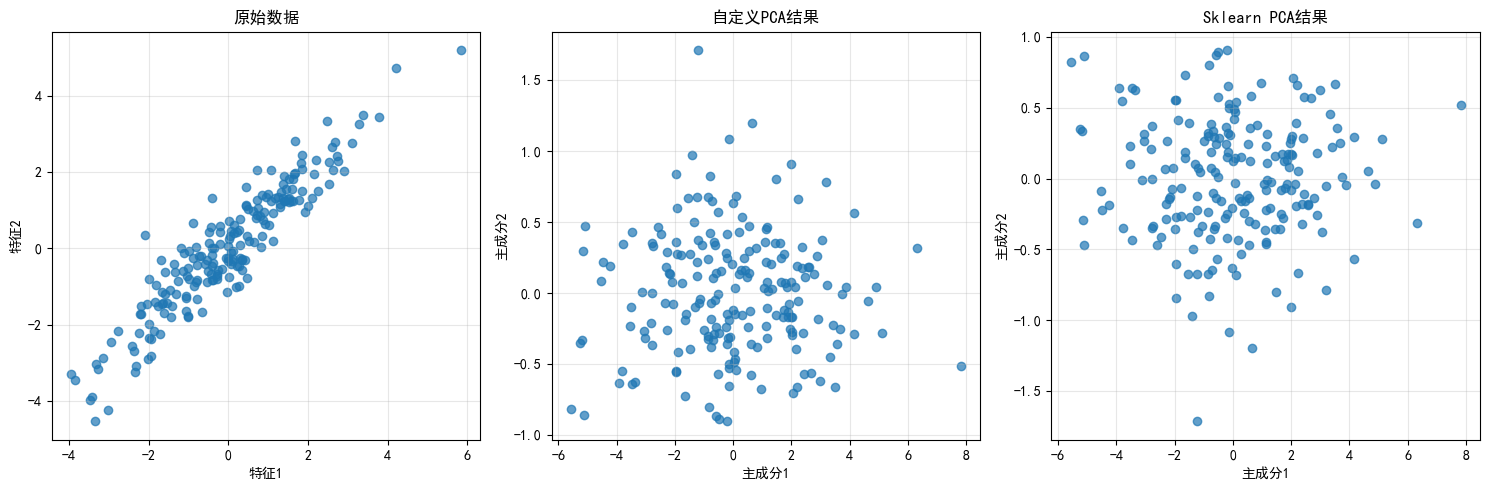


=== PCA肘部图演示 ===
数据形状: (300, 10)


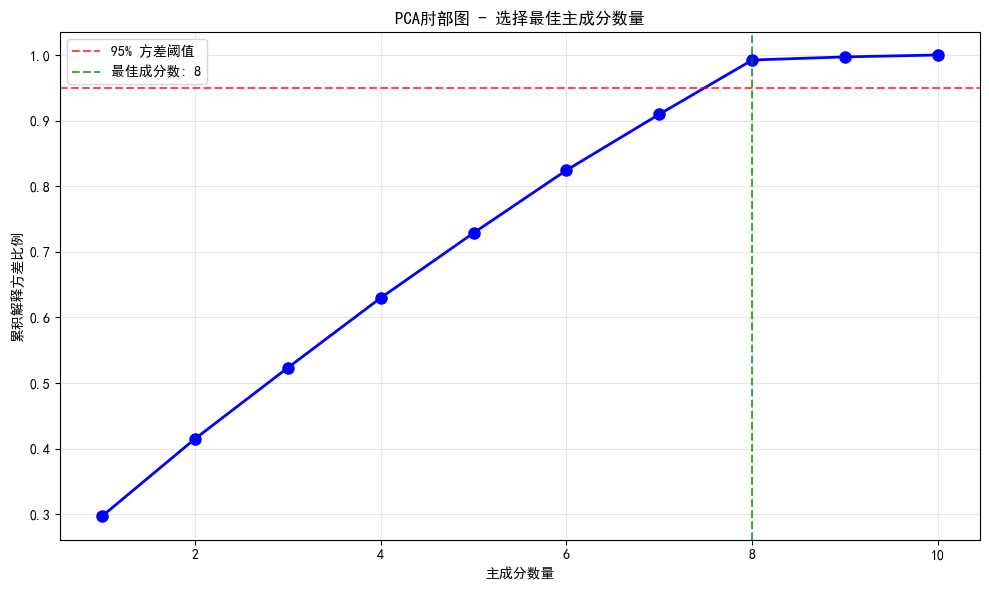

达到95%解释方差所需的最小主成分数: 8

=== 鸢尾花数据集PCA演示 ===
数据形状: (150, 4)
特征名: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
目标类别: ['setosa' 'versicolor' 'virginica']
PCA后数据形状: (150, 2)
解释方差比例: [0.72962445 0.22850762]
总解释方差: 0.958


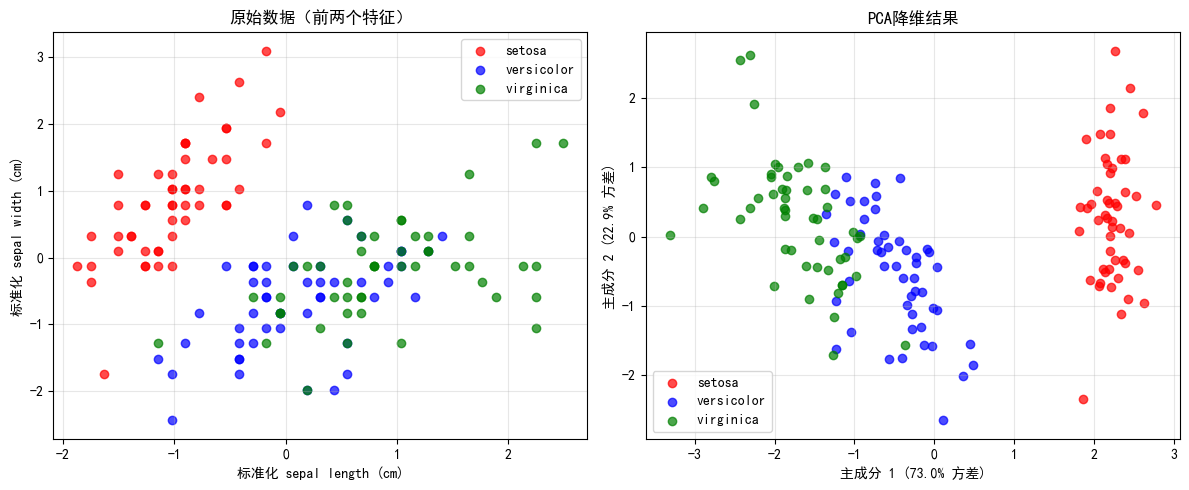


主成分组成分析:
主成分 1:
  sepal length (cm): -0.521
  sepal width (cm): 0.269
  petal length (cm): -0.580
  petal width (cm): -0.565
主成分 2:
  sepal length (cm): 0.377
  sepal width (cm): 0.923
  petal length (cm): 0.024
  petal width (cm): 0.067

=== PCA数据压缩演示 ===
原始图像数据形状: (5, 64)
每个图像的特征数: 64
压缩后数据形状: (5, 3)
压缩比: 21.3x
保留方差比例: 1.000


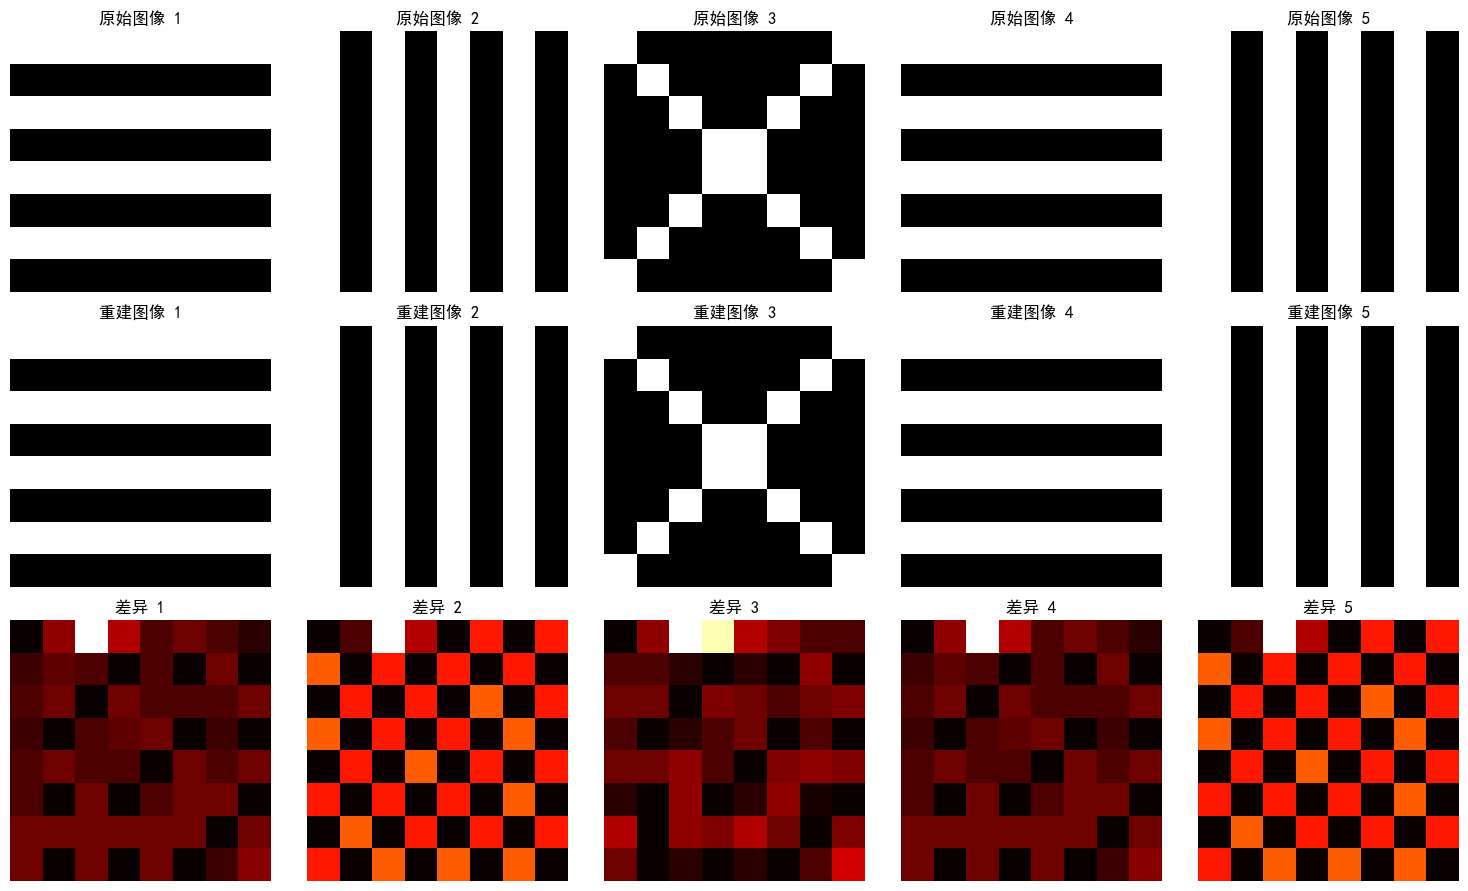

平均重建误差: 0.000000

=== PCA特征重要性分析 ===


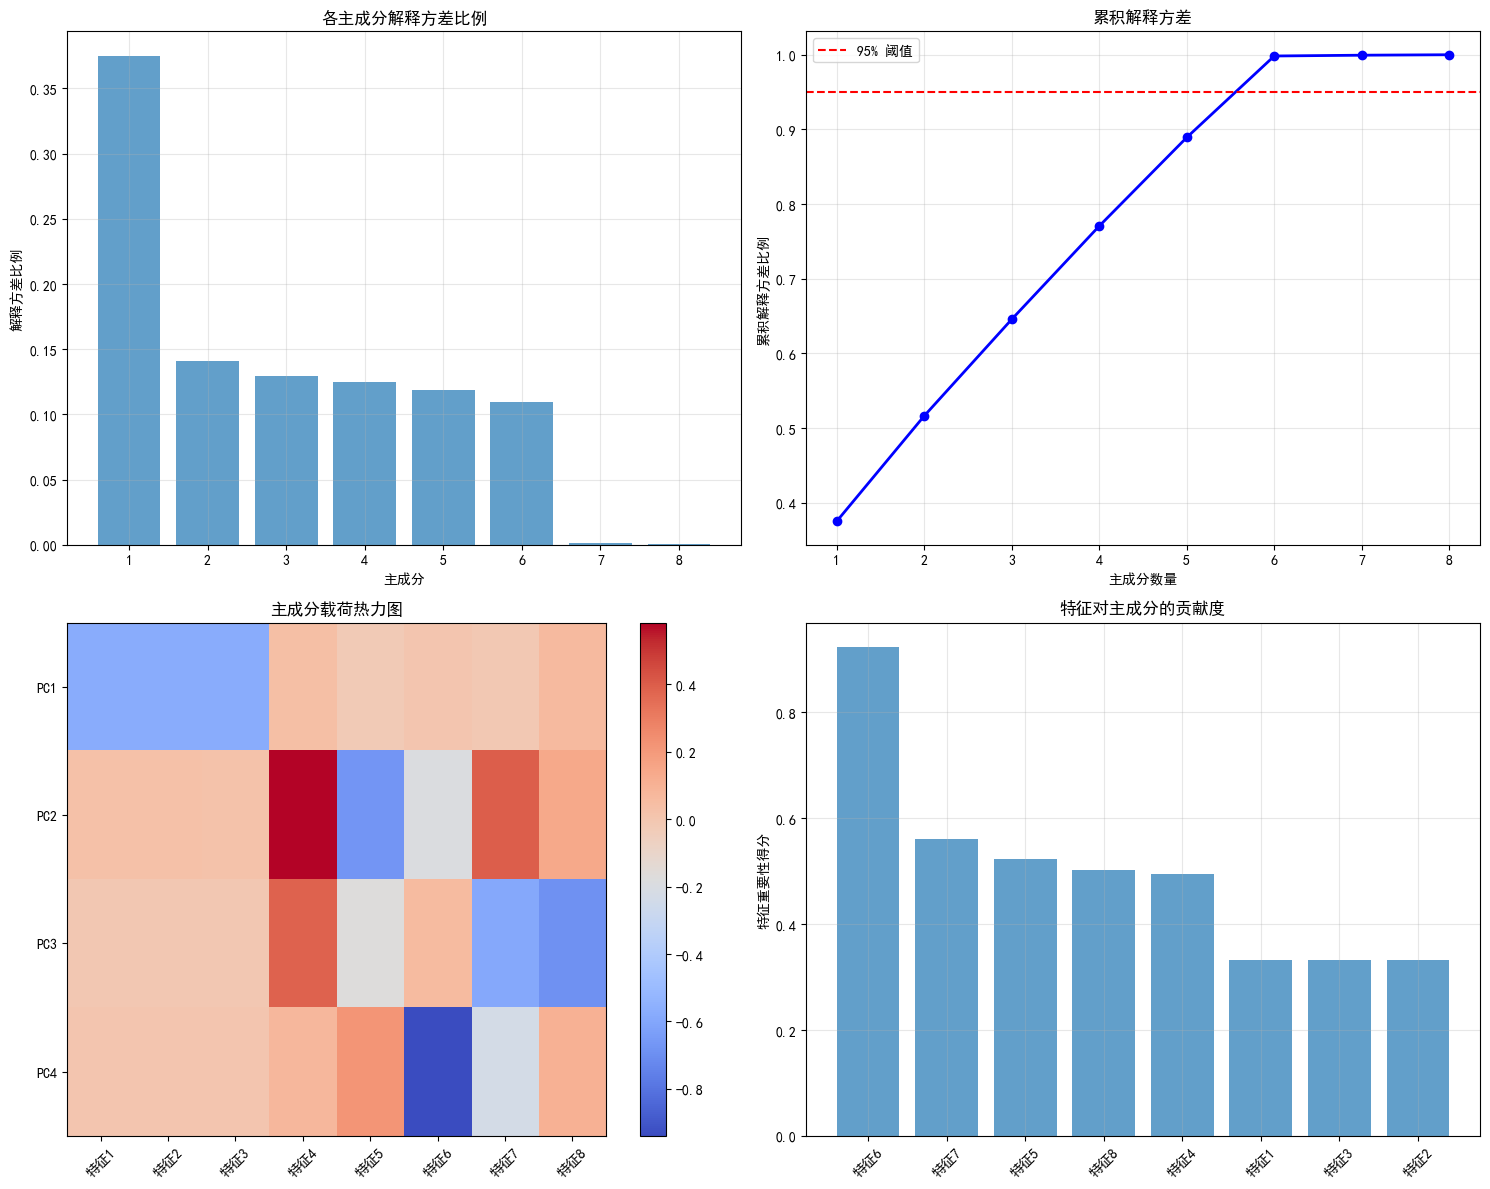

特征重要性排名:
1. 特征6: 0.923
2. 特征7: 0.561
3. 特征5: 0.523
4. 特征8: 0.502
5. 特征4: 0.495
6. 特征1: 0.332
7. 特征3: 0.332
8. 特征2: 0.332

=== 超简洁PCA使用示例 ===
输入数据形状: (100, 5)
PCA后数据形状: (100, 2)

=== 总结 ===
 实现了完整的PCA算法
 演示了肘部图选择主成分数量
 在鸢尾花数据集上验证了效果
 展示了数据压缩应用
 分析了特征重要性
 提供了简洁实现版本


In [1]:
# %load 4-3.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
import warnings
warnings.filterwarnings('ignore')

class SimplePCA:
    """
    简单PCA实现类
    """
    
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
        self.fitted = False
    
    def fit(self, X):
        """
        训练PCA模型
        
        参数:
        X: 输入数据，形状为 (n_samples, n_features)
        """
        # 数据标准化
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # 计算协方差矩阵
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # 计算特征值和特征向量
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # 按特征值降序排序
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        
        # 选择主成分数量
        if self.n_components is None:
            self.n_components = X.shape[1]
        
        # 保存结果
        self.components_ = eigenvectors[:, :self.n_components].T
        self.explained_variance_ = eigenvalues[:self.n_components]
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        
        self.fitted = True
        return self
    
    def transform(self, X):
        """
        将数据转换到主成分空间
        
        参数:
        X: 输入数据
        
        返回:
        转换后的数据
        """
        if not self.fitted:
            raise ValueError("PCA模型尚未训练，请先调用fit方法")
        
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_.T)
    
    def fit_transform(self, X):
        """训练并转换数据"""
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X_transformed):
        """
        将主成分空间的数据转换回原始空间
        
        参数:
        X_transformed: 主成分空间的数据
        
        返回:
        原始空间的数据
        """
        if not self.fitted:
            raise ValueError("PCA模型尚未训练")
        
        return np.dot(X_transformed, self.components_) + self.mean_
    
    def get_cumulative_variance(self):
        """获取累积解释方差"""
        if not self.fitted:
            raise ValueError("PCA模型尚未训练")
        
        return np.cumsum(self.explained_variance_ratio_)

def demo_pca_implementation():
    """
    PCA实现演示
    """
    print("=== PCA实现演示 ===")
    
    # 创建示例数据
    np.random.seed(42)
    n_samples = 200
    
    # 生成相关数据
    X = np.random.multivariate_normal(
        mean=[0, 0],
        cov=[[3, 2.8], [2.8, 3]],
        size=n_samples
    )
    
    print(f"原始数据形状: {X.shape}")
    print(f"原始数据前5行:\n{X[:5]}")
    
    # 1. 使用自定义PCA
    print("\n1. 自定义PCA实现")
    pca = SimplePCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    print(f"主成分形状: {X_pca.shape}")
    print(f"主成分前5行:\n{X_pca[:5]}")
    print(f"解释方差比例: {pca.explained_variance_ratio_}")
    print(f"累积解释方差: {pca.get_cumulative_variance()}")
    
    # 2. 与sklearn PCA对比
    print("\n2. 与sklearn PCA对比")
    sklearn_pca = SklearnPCA(n_components=2)
    X_sklearn_pca = sklearn_pca.fit_transform(X)
    
    print(f"Sklearn解释方差比例: {sklearn_pca.explained_variance_ratio_}")
    
    # 可视化比较
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 原始数据
    axes[0].scatter(X[:, 0], X[:, 1], alpha=0.7)
    axes[0].set_xlabel('特征1')
    axes[0].set_ylabel('特征2')
    axes[0].set_title('原始数据')
    axes[0].grid(True, alpha=0.3)
    
    # 自定义PCA结果
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
    axes[1].set_xlabel('主成分1')
    axes[1].set_ylabel('主成分2')
    axes[1].set_title('自定义PCA结果')
    axes[1].grid(True, alpha=0.3)
    
    # Sklearn PCA结果
    axes[2].scatter(X_sklearn_pca[:, 0], X_sklearn_pca[:, 1], alpha=0.7)
    axes[2].set_xlabel('主成分1')
    axes[2].set_ylabel('主成分2')
    axes[2].set_title('Sklearn PCA结果')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return X, X_pca, X_sklearn_pca

def pca_elbow_plot():
    """
    肘部图 - 选择最佳主成分数量
    """
    print("\n=== PCA肘部图演示 ===")
    
    # 创建更高维度的数据
    np.random.seed(42)
    n_samples = 300
    n_features = 10
    
    # 生成数据（前3个维度有强相关性，其余为噪声）
    X = np.random.randn(n_samples, n_features)
    # 使前3个特征相关
    X[:, 1] = X[:, 0] * 0.8 + np.random.normal(0, 0.2, n_samples)
    X[:, 2] = X[:, 0] * 0.6 + X[:, 1] * 0.4 + np.random.normal(0, 0.2, n_samples)
    
    print(f"数据形状: {X.shape}")
    
    # 标准化数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 计算不同主成分数量下的解释方差
    max_components = min(X_scaled.shape[1], 10)
    explained_variances = []
    
    for n_comp in range(1, max_components + 1):
        pca = SimplePCA(n_components=n_comp)
        pca.fit(X_scaled)
        explained_variances.append(np.sum(pca.explained_variance_ratio_))
    
    # 绘制肘部图
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_components + 1), explained_variances, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('主成分数量')
    plt.ylabel('累积解释方差比例')
    plt.title('PCA肘部图 - 选择最佳主成分数量')
    plt.grid(True, alpha=0.3)
    
    # 添加阈值线（通常选择解释95%方差的成分数）
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% 方差阈值')
    plt.legend()
    
    # 找到达到95%方差所需的最小成分数
    min_components = np.argmax(np.array(explained_variances) >= 0.95) + 1
    plt.axvline(x=min_components, color='g', linestyle='--', alpha=0.7, 
                label=f'最佳成分数: {min_components}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"达到95%解释方差所需的最小主成分数: {min_components}")
    
    return X_scaled, explained_variances

def iris_pca_demo():
    """
    在鸢尾花数据集上演示PCA
    """
    print("\n=== 鸢尾花数据集PCA演示 ===")
    
    # 加载鸢尾花数据集
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names
    
    print(f"数据形状: {X.shape}")
    print(f"特征名: {feature_names}")
    print(f"目标类别: {target_names}")
    
    # 标准化数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 应用PCA
    pca = SimplePCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"PCA后数据形状: {X_pca.shape}")
    print(f"解释方差比例: {pca.explained_variance_ratio_}")
    print(f"总解释方差: {np.sum(pca.explained_variance_ratio_):.3f}")
    
    # 可视化PCA结果
    plt.figure(figsize=(12, 5))
    
    # 原始数据的前两个特征
    plt.subplot(1, 2, 1)
    colors = ['red', 'blue', 'green']
    for i, color in enumerate(colors):
        plt.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], 
                   color=color, alpha=0.7, label=target_names[i])
    plt.xlabel('标准化 ' + feature_names[0])
    plt.ylabel('标准化 ' + feature_names[1])
    plt.title('原始数据（前两个特征）')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # PCA结果
    plt.subplot(1, 2, 2)
    for i, color in enumerate(colors):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                   color=color, alpha=0.7, label=target_names[i])
    plt.xlabel('主成分 1 ({:.1f}% 方差)'.format(pca.explained_variance_ratio_[0] * 100))
    plt.ylabel('主成分 2 ({:.1f}% 方差)'.format(pca.explained_variance_ratio_[1] * 100))
    plt.title('PCA降维结果')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 分析主成分的组成
    print("\n主成分组成分析:")
    for i, component in enumerate(pca.components_):
        print(f"主成分 {i+1}:")
        for j, weight in enumerate(component):
            print(f"  {feature_names[j]}: {weight:.3f}")
    
    return X_scaled, X_pca, y, feature_names, target_names

def pca_for_compression():
    """
    PCA数据压缩演示
    """
    print("\n=== PCA数据压缩演示 ===")
    
    # 创建模拟图像数据（8x8像素）
    np.random.seed(42)
    n_images = 5
    image_size = 8
    
    # 生成简单的图像模式
    images = []
    for i in range(n_images):
        # 创建有规律的图像
        img = np.zeros((image_size, image_size))
        
        # 添加不同的模式
        if i % 3 == 0:
            # 水平条纹
            for j in range(image_size):
                if j % 2 == 0:
                    img[j, :] = 1
        elif i % 3 == 1:
            # 垂直条纹
            for j in range(image_size):
                if j % 2 == 0:
                    img[:, j] = 1
        else:
            # 对角线条纹
            for j in range(image_size):
                img[j, j] = 1
                img[j, image_size-1-j] = 1
        
        images.append(img.flatten())
    
    X = np.array(images)
    print(f"原始图像数据形状: {X.shape}")
    print(f"每个图像的特征数: {X.shape[1]}")
    
    # 应用PCA进行压缩
    pca = SimplePCA(n_components=3)  # 压缩到3个主成分
    X_pca = pca.fit_transform(X)
    
    print(f"压缩后数据形状: {X_pca.shape}")
    print(f"压缩比: {X.shape[1] / X_pca.shape[1]:.1f}x")
    print(f"保留方差比例: {np.sum(pca.explained_variance_ratio_):.3f}")
    
    # 重建图像
    X_reconstructed = pca.inverse_transform(X_pca)
    
    # 可视化原始和重建图像
    fig, axes = plt.subplots(3, n_images, figsize=(15, 9))
    
    for i in range(n_images):
        # 原始图像
        axes[0, i].imshow(X[i].reshape(image_size, image_size), cmap='gray')
        axes[0, i].set_title(f'原始图像 {i+1}')
        axes[0, i].axis('off')
        
        # 重建图像
        axes[1, i].imshow(X_reconstructed[i].reshape(image_size, image_size), cmap='gray')
        axes[1, i].set_title(f'重建图像 {i+1}')
        axes[1, i].axis('off')
        
        # 差异
        diff = np.abs(X[i] - X_reconstructed[i]).reshape(image_size, image_size)
        axes[2, i].imshow(diff, cmap='hot')
        axes[2, i].set_title(f'差异 {i+1}')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 计算重建误差
    reconstruction_error = np.mean((X - X_reconstructed) ** 2)
    print(f"平均重建误差: {reconstruction_error:.6f}")
    
    return X, X_pca, X_reconstructed

def pca_feature_importance():
    """
    PCA特征重要性分析
    """
    print("\n=== PCA特征重要性分析 ===")
    
    # 创建具有明显重要性的特征数据
    np.random.seed(42)
    n_samples = 500
    n_features = 8
    
    # 生成数据：前3个特征重要，后5个为噪声
    X = np.random.randn(n_samples, n_features)
    
    # 创建重要特征的相关性
    X[:, 1] = X[:, 0] * 0.9 + np.random.normal(0, 0.1, n_samples)
    X[:, 2] = X[:, 0] * 0.7 + X[:, 1] * 0.3 + np.random.normal(0, 0.1, n_samples)
    
    feature_names = [f'特征{i+1}' for i in range(n_features)]
    
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 应用PCA
    pca = SimplePCA(n_components=n_features)
    pca.fit(X_scaled)
    
    # 可视化特征重要性
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. 解释方差比例
    axes[0, 0].bar(range(1, n_features + 1), pca.explained_variance_ratio_, alpha=0.7)
    axes[0, 0].set_xlabel('主成分')
    axes[0, 0].set_ylabel('解释方差比例')
    axes[0, 0].set_title('各主成分解释方差比例')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 累积解释方差
    cumulative_variance = pca.get_cumulative_variance()
    axes[0, 1].plot(range(1, n_features + 1), cumulative_variance, 'bo-', linewidth=2)
    axes[0, 1].set_xlabel('主成分数量')
    axes[0, 1].set_ylabel('累积解释方差比例')
    axes[0, 1].set_title('累积解释方差')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0.95, color='r', linestyle='--', label='95% 阈值')
    axes[0, 1].legend()
    
    # 3. 主成分载荷热力图（前4个主成分）
    n_show_components = min(4, n_features)
    loadings = pca.components_[:n_show_components, :]
    
    im = axes[1, 0].imshow(loadings, cmap='coolwarm', aspect='auto')
    axes[1, 0].set_xticks(range(n_features))
    axes[1, 0].set_xticklabels(feature_names, rotation=45)
    axes[1, 0].set_yticks(range(n_show_components))
    axes[1, 0].set_yticklabels([f'PC{i+1}' for i in range(n_show_components)])
    axes[1, 0].set_title('主成分载荷热力图')
    
    # 添加颜色条
    plt.colorbar(im, ax=axes[1, 0])
    
    # 4. 特征对主成分的贡献度
    feature_importance = np.sum(loadings ** 2, axis=0)
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    axes[1, 1].bar(range(n_features), feature_importance[sorted_idx], alpha=0.7)
    axes[1, 1].set_xticks(range(n_features))
    axes[1, 1].set_xticklabels([feature_names[i] for i in sorted_idx], rotation=45)
    axes[1, 1].set_ylabel('特征重要性得分')
    axes[1, 1].set_title('特征对主成分的贡献度')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印特征重要性排名
    print("特征重要性排名:")
    for i, idx in enumerate(sorted_idx):
        print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.3f}")
    
    return X_scaled, pca, feature_names

# 简洁版本
def quick_pca(X, n_components=2):
    """
    超简洁的PCA实现
    
    参数:
    X: 输入数据 (n_samples, n_features)
    n_components: 主成分数量
    
    返回:
    转换后的数据
    """
    # 中心化
    X_centered = X - np.mean(X, axis=0)
    
    # 计算协方差矩阵的特征分解
    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # 选择前n_components个主成分
    idx_sorted = np.argsort(eigenvalues)[::-1]
    components = eigenvectors[:, idx_sorted[:n_components]]
    
    # 投影数据
    return np.dot(X_centered, components)

if __name__ == "__main__":
    print("PCA实现完整演示")
    print("=" * 60)
    
    # 运行所有演示
    X_orig, X_custom, X_sklearn = demo_pca_implementation()
    
    X_scaled_elbow, explained_vars = pca_elbow_plot()
    
    X_iris, X_iris_pca, y_iris, feature_names, target_names = iris_pca_demo()
    
    X_images, X_compressed, X_reconstructed = pca_for_compression()
    
    X_importance, pca_model, feature_names = pca_feature_importance()
    
    # 超简洁版本使用示例
    print("\n=== 超简洁PCA使用示例 ===")
    np.random.seed(42)
    test_data = np.random.randn(100, 5)
    test_pca = quick_pca(test_data, n_components=2)
    print(f"输入数据形状: {test_data.shape}")
    print(f"PCA后数据形状: {test_pca.shape}")
    
    print("\n=== 总结 ===")
    print(" 实现了完整的PCA算法")
    print(" 演示了肘部图选择主成分数量")
    print(" 在鸢尾花数据集上验证了效果")
    print(" 展示了数据压缩应用")
    print(" 分析了特征重要性")
    print(" 提供了简洁实现版本")